# GraphSLAM Assignment

In this assignment, you will implement a step-by-step Graph SLAM exercise. Fill in the code cells marked `# TODO`. Do not modify the headings; submit this notebook with your completed code cells. 

## 1. Setup and Imports

Before starting, make sure you have selected the right Python interpreter. Setting the wrong interpreter will most likely lead to errors about modules not being found in the block below (this can be set in the upper right corner of your screen and it must be: graph-slam).

Import the necessary libraries. If you're running in Colab, install `gtsam` as needed. Keep imports here so later cells can use them.

In [1]:

# Enable autoreload in Jupyter Notebook before the imports
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import graphviz
import gtsam
import gtsam.utils.plot as gp
from gtsam.symbol_shorthand import L, X
from helperfunctions import add_pose_from_global, add_landmark_measurement_from_global



## 2. Define Noise Models

Here, we define the noise models used in the assignment. We introduce appropriate standard deviations. These noise models introduce a realistic robotics scenario where SLAM is executed with noisy sensors and measurements.

In [2]:
PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1, 0.05]))  # (x, y, theta)
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))  # (dx, dy, dtheta)
MEASUREMENT_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.1]))  # (bearing, range)

## 3. Build the Factor Graph

Create the factor graph step-by-step. For each step, complete the code cell below. A factor graph is a bipartite graph that enables integration of heterogeneous measurements to estimate the most likely state of the world. Hence, since we are dealing with robotic sensors and measurements, aiming to perform Graph SLAM, factor graphs are a useful tool.

In [3]:
# Create an empty nonlinear factor graph
graph = gtsam.NonlinearFactorGraph()

# Keep shorthand: X(i) for poses, L(j) for landmarks (imported above)

### 3.1 Add a Prior Factor

To "anchor" the graph, we add a prior factor on the first pose $x_1$. This represents our initial belief about where the robot started. We assume it started at the origin (0, 0, 0) with the uncertainty defined by `PRIOR_NOISE`.


In [5]:
# A prior factor consists of a mean (gtsam.Pose2) and a noise model.
graph.add(gtsam.PriorFactorPose2(X(1), gtsam.Pose2(0.0, 0.0, 0.0), PRIOR_NOISE))

### 3.2 Add Odometry Factors

Next, we add factors representing the robot's movement based on odometry measurements. We assume the robot moved approximately 2 units forward in the x-direction between each pose.

A `BetweenFactorPose2` connects two consecutive poses (e.g., $x_1$ and $x_2$) and represents the measured relative motion between them (`gtsam.Pose2(2.0, 0.0, 0.0)`) with its associated noise (`ODOMETRY_NOISE`).

In [6]:
# Between X(1) and X(2): Move forward 2m
graph.add(gtsam.BetweenFactorPose2(X(1), X(2), gtsam.Pose2(2.0, 0.0, 0.0), ODOMETRY_NOISE))
# Between X(2) and X(3): Move forward 2m
graph.add(gtsam.BetweenFactorPose2(X(2), X(3), gtsam.Pose2(2.0, 0.0, 0.0), ODOMETRY_NOISE))

### 3.3 Add Bearing-Range Measurements

Now, add factors representing the LiDAR's bearing-range measurements from the robot's poses to the landmarks. The bearing represents the angle and the range the distance (polar coordinates).

A `BearingRangeFactor2D` connects a pose variable (e.g., $x_1$) and a landmark variable (e.g., $l_1$). It includes the measured bearing (`gtsam.Rot2`) and range (distance), along with the measurement noise (`MEASUREMENT_NOISE`).

We have three measurements:
*   From $x_1$ to $l_1$: Bearing 45 degrees, Range sqrt(8)
*   From $x_2$ to $l_1$: Bearing 90 degrees, Range 2.0
*   From $x_3$ to $l_2$: Bearing 90 degrees, Range 2.0

In [7]:
# From X(1) to L(1)
graph.add(gtsam.BearingRangeFactor2D(X(1), L(1), gtsam.Rot2.fromDegrees(45), np.sqrt(4.0+4.0), MEASUREMENT_NOISE))
# From X(2) to L(1)
graph.add(gtsam.BearingRangeFactor2D(X(2), L(1), gtsam.Rot2.fromDegrees(90), 2.0, MEASUREMENT_NOISE))
# From X(3) to L(2)
graph.add(gtsam.BearingRangeFactor2D(X(3), L(2), gtsam.Rot2.fromDegrees(90), 2.0, MEASUREMENT_NOISE))

### 3.4 Inspect the Graph

Print a summary of the graph. 

In [8]:
# Print a textual summary of the graph
print('Factor Graph:{}'.format(graph))


Factor Graph:NonlinearFactorGraph: size: 7

Factor 0: PriorFactor on x1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.1; 0.1; 0.05];

Factor 1: PriorFactor on x1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.1; 0.1; 0.05];

Factor 2: BetweenFactor(x1,x2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 3: BetweenFactor(x2,x3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 4: BearingRangeFactor
Factor 4:   keys = { x1 l1 }
  noise model: diagonal sigmas [0.05; 0.1];
ExpressionFactor with measurement: bearing : 0.785398163
range  2.82842712

Factor 5: BearingRangeFactor
Factor 5:   keys = { x2 l1 }
  noise model: diagonal sigmas [0.05; 0.1];
ExpressionFactor with measurement: bearing : 1.57079633
range  2

Factor 6: BearingRangeFactor
Factor 6:   keys = { x3 l2 }
  noise model: diagonal sigmas [0.05; 0.1];
ExpressionFactor with measurement: bearing : 1.57079633
range  2




## 4. Create Initial Estimate

Factor graph optimization is an iterative process that needs an initial guess (initial estimate) for the values of all unknown variables. The closer the initial estimate is to the true solution, the faster and more reliably the optimizer will converge.

Here, we create a `gtsam.Values` object and deliberately insert slightly *inaccurate* initial estimates for the poses and landmark positions. You will see later that the optimizer can correct for errors in the initial guess.

Initial Estimate:
Values with 5 values:
Value l1: (class Eigen::Matrix<double,-1,1,0,-1,1>)
[
	1.8;
	2.1
]

Value l2: (class Eigen::Matrix<double,-1,1,0,-1,1>)
[
	4.1;
	1.8
]

Value x1: (class gtsam::Pose2)
(-0.25, 0.2, 0.15)

Value x2: (class gtsam::Pose2)
(2.3, 0.1, -0.2)

Value x3: (class gtsam::Pose2)
(4.1, 0.1, 0.1)




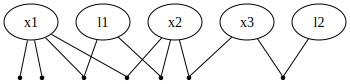

In [9]:
# gtsam.Values is a container mapping variable keys to their estimated values.
initial_estimate = gtsam.Values()

# Insert initial guesses for poses (Pose2: x, y, theta)
initial_estimate.insert(X(1), gtsam.Pose2(-0.25, 0.20, 0.15))
initial_estimate.insert(X(2), gtsam.Pose2(2.30, 0.10, -0.20))
initial_estimate.insert(X(3), gtsam.Pose2(4.10, 0.10, 0.10))

# Insert initial guesses for landmarks (Point2: x, y)
initial_estimate.insert(L(1), gtsam.Point2(1.80, 2.10))
initial_estimate.insert(L(2), gtsam.Point2(4.10, 1.80))

# Print the initial estimate
print("Initial Estimate:\n{}".format(initial_estimate))

# Visualize the graph (run "sudo apt install graphviz" in your terminal if you get an error about missing Graphviz)
display(graphviz.Source(graph.dot(initial_estimate)))

## 5. Optimize the Factor Graph

Now, we use an optimizer to find the variable configuration that best fits all the factors (measurements) in the graph, starting from the initial estimate.

We'll use the Levenberg-Marquardt (LM) algorithm, a standard non-linear least-squares optimizer.

In [10]:
# Creating LM parameters (`gtsam.LevenbergMarquardtParams`). We'll use the defaults.
params = gtsam.LevenbergMarquardtParams()
# Creating the optimizer instance, providing the graph, initial estimate, and parameters.
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimate, params)
# Running the optimization
result = optimizer.optimize()
# Print the optimized result
print("\nFinal Result:\n{}".format(result))


Final Result:
Values with 5 values:
Value l1: (class Eigen::Matrix<double,-1,1,0,-1,1>)
[
	2;
	2
]

Value l2: (class Eigen::Matrix<double,-1,1,0,-1,1>)
[
	4;
	2
]

Value x1: (class gtsam::Pose2)
(-2.03981416e-17, -5.44073586e-17, -6.01737166e-17)

Value x2: (class gtsam::Pose2)
(2, -7.9033925e-16, -6.29188329e-16)

Value x3: (class gtsam::Pose2)
(4, -5.80223346e-14, -6.57429837e-16)




## 6. Visualize Optimized Poses and Landmarks

The code below visualizes the optimized poses and landmarks in 2D. It uses GTSAM's plotting utilities to plot the robot's trajectory (poses) and the estimated positions of the landmarks. The poses are represented as coordinate frames indicating the robot's orientation, while the landmarks are plotted as blue points. 

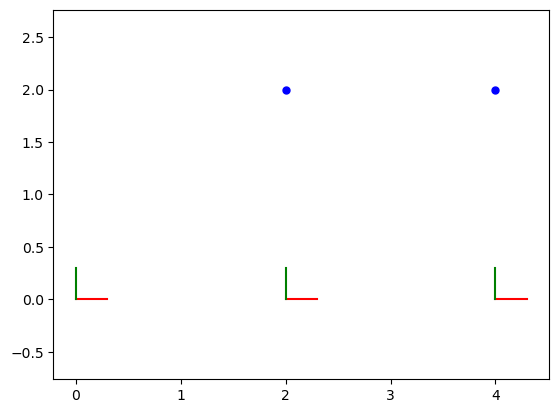

In [11]:
fig = plt.figure(1)
axes = fig.add_subplot()
axes = fig.axes[0]

# Plot 2D poses
poses : gtsam.Values = gtsam.utilities.allPose2s(result)
for key in poses.keys():
    pose = poses.atPose2(key)
    gp.plot_pose2_on_axes(axes, pose, axis_length=0.3)

# Plot 2D landmarks
landmarks : np.ndarray = gtsam.utilities.extractPoint2(result) # 2xn array
for landmark in landmarks:
    gp.plot_point2_on_axes(axes, landmark, linespec="b")

axes.set_aspect("equal", adjustable="datalim")

## 7. Calculate Marginal Covariances

Besides finding the optimal values (the mean), GTSAM can also compute the uncertainty (covariance) associated with each variable estimate after optimization. This tells us how confident we are about the estimated poses and landmark locations.

We use the `gtsam.Marginals` class to calculate the marginal covariance matrices for each variable.
Each pose covariance matrix is a 3x3 matrix because a pose in 2D (`Pose2`) has three components: `(x, y, theta)` Each landmark covariance matrix is a 2x2 matrix because a landmark in 2D is represented by its `(x, y)` position.


In [12]:
# Calculating marginal covariances for all variables.
marginals = gtsam.Marginals(graph, result)

# Print the covariance matrix for each variable
print("X1 covariance:\n{}\n".format(marginals.marginalCovariance(X(1))))
print("X2 covariance:\n{}\n".format(marginals.marginalCovariance(X(2))))
print("X3 covariance:\n{}\n".format(marginals.marginalCovariance(X(3))))
print("L1 covariance:\n{}\n".format(marginals.marginalCovariance(L(1))))
print("L2 covariance:\n{}\n".format(marginals.marginalCovariance(L(2))))

X1 covariance:
[[ 5.00000000e-03 -8.88178420e-20  2.66453526e-19]
 [-8.88178420e-20  5.00000000e-03  1.77635684e-19]
 [ 2.66453526e-19  1.77635684e-19  1.25000000e-03]]

X2 covariance:
[[ 0.02970588 -0.00117647  0.00764706]
 [-0.00117647  0.02529412  0.00308824]
 [ 0.00764706  0.00308824  0.00742647]]

X3 covariance:
[[0.06970588 0.01411765 0.00764706]
 [0.01411765 0.10735294 0.01794118]
 [0.00764706 0.01794118 0.01742647]]

L1 covariance:
[[ 0.02257353 -0.00830882]
 [-0.00830882  0.02139706]]

L2 covariance:
[[ 0.11882353 -0.02176471]
 [-0.02176471  0.11735294]]



The code below once again visualizes the optimized poses and landmarks, now with their associated uncertainties (covariances).
The covariance ellipses plotted on the graph visually represent the uncertainty in the estimates. Larger ellipses indicate higher uncertainty, while smaller ellipses indicate more confident estimates.

The prior is on $x_1$, at the origin, and hence that is the most certain pose, after which uncertainty increases. Note that for poses we only show the uncertainty on translation, although each pose also has an uncertain orientation. The covariance ellipses on the landmarks actually reflect that orientation uncertainty, being oriented the way they are.

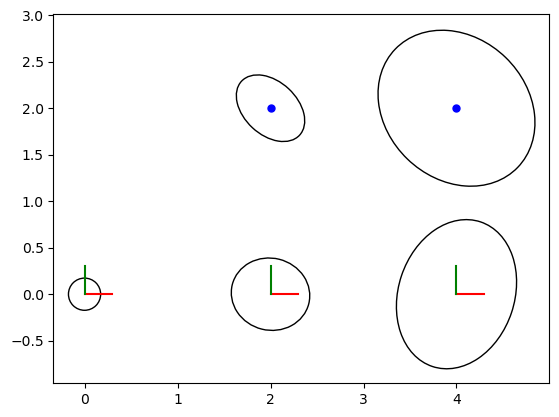

In [13]:
fig = plt.figure(2)
axes = fig.add_subplot()
axes = fig.axes[0]

# Plot 2D poses
poses = gtsam.utilities.allPose2s(result)
for key in poses.keys():
    pose = poses.atPose2(key)
    covariance = marginals.marginalCovariance(key)

    gp.plot_pose2_on_axes(axes, pose, covariance=covariance, axis_length=0.3)

# Plot 2D landmarks
landmarks: np.ndarray = gtsam.utilities.extractPoint2(result)  # 2xn array
for j, landmark in enumerate(landmarks):
    gp.plot_point2_on_axes(axes, landmark, linespec="b")
    covariance = marginals.marginalCovariance(L(j+1))
    gp.plot_covariance_ellipse_2d(axes, landmark, covariance=covariance)

axes.set_aspect("equal", adjustable="datalim")

## 8. Continuing Graph SLAM

Up to now, we have successfully:
1.  Defined the structure of a 2D SLAM problem using factors (prior, odometry, measurements) and variables (poses, landmarks).
2.  Represented this problem as a `gtsam.NonlinearFactorGraph`.
3.  Provided noisy measurements and an inaccurate initial estimate.
4.  Used `gtsam.LevenbergMarquardtOptimizer` to find the most likely configuration of poses and landmarks.
5.  Calculated the uncertainty (covariance) of the final estimates.

Graph SLAM is an iterative process where we add new measurements as the robot moves on. In the following exercises, you continue by adding new measurements. Look back to the previous exercises for hints on implementation. For each assignment, implement the code (`# TODO`). Use the code cells below as scaffolds.

### 8.1 Add a 4th pose X(4)

Add odometry between X(3) and X(4) such that the robot rotates ~45 degrees (anti-clockwise) and moves ~2 meters and then rotates ~45 degrees more (anti-clockwise) . Insert an initial guess and odometry measurement for X(4).

In [ ]:
# Enable autoreload in Jupyter Notebook before the imports
%load_ext autoreload
%autoreload 2

# TODO: Add X(4) odometry factor and initial estimate in add_pose.py
from src.add_pose import add_pose
graph, initial_estimate = add_pose(graph, initial_estimate)

In [18]:
# Run this cell to test your implementation
# The exclamation markt is used to run shell commands from within the notebook
!pytest tests/test_1a_add_pose.py tests/test_1b_add_pose.py -v



============================= test session starts =============================
platform win32 -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\20241314\.conda\envs\graph-slam\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\20241314\OneDrive - TU Eindhoven\Git files\Second graded programming assignement\graph-slam-graded-i-gerards
collecting ... collected 2 items

tests/test_1a_add_pose.py::test_add_pose PASSED                          [ 50%]
tests/test_1b_add_pose.py::test_add_pose FAILED                          [100%]

================================== FAILURES ===================================
________________________________ test_add_pose ________________________________

    def test_add_pose():
        # Test that the add_pose function correctly adds a new pose to the graph and updates the initial estimate accordingly.
        # Load test graph and estimate files
        with open('tests/test_add_pose_graph.pkl', 'rb') as inp:
            graph = pickle.load(inp

Now we optimize again and visualize the result.

In [17]:
# Optimize using Levenberg-Marquardt optimization.

# Perform the optimization


# Calculate marginal covariances for all variables.

# Visualize the updated factor graph


# Plot 2D poses


# Plot 2D landmarks


### 8.2 Add a measurement from X(4) to a landmark

Add a bearing-range measurement from X(4) to landmark L(2). Re-optimize and report the new covariance for that landmark. 

In [ ]:
# Enable autoreload in Jupyter Notebook before the imports
%load_ext autoreload
%autoreload 2

# TODO: Add the measurement from X(4) to landmark L(2) in add_landmark_measurement.py
from src.add_landmark_measurement import add_landmark_measurement
graph = add_landmark_measurement(graph, initial_estimate, result)



In [ ]:
# Run this cell to test your implementation
# The exclamation markt is used to run shell commands from within the notebook
!pytest tests/test_2a_add_landmark_measurement.py tests/test_2b_add_landmark_measurement.py -v

## 9 Add a 5th pose X(5) 

After adding the first 4 poses, you may decide the next best position for the robot to go to.

Consider the four candidate global positions for X(5):
- A: (0, 3)
- B: (0, 0)
- C: (4, 3)
- D: (2, 3)

Add X(5) at each option separately, add a measurement from X(5) to one chosen landmark, and record the landmark covariance sums. Which option reduces landmark covariance most? Provide your code in pose_5.py

### 9.1 Adding pose X(5) 

In [ ]:
# Enable autoreload in Jupyter Notebook before the imports
%load_ext autoreload
%autoreload 2

from src.pose_5 import minimize_marginals
# Global pose of X(4) (already in initial_estimate)
pose_4 = initial_estimate.atPose2(X(4))
# ---------------------------------------------------------
# Candidate global positions for X(5)
# (heading chosen equal to pose_4 to avoid artificial rotation)
# ---------------------------------------------------------
pose_options = {
    "a": gtsam.Pose2(0.0, 3.0, pose_4.theta()),
    "b": gtsam.Pose2(0.0, 0.0, pose_4.theta()),
    "c": gtsam.Pose2(4.0, 3.0, pose_4.theta()),
    "d": gtsam.Pose2(2.0, 3.0, pose_4.theta()),
}
# TODO: Implement the "optimize" and "minimize_marginals" functions in pose_5.py
best_pose, best_landmark, marginals = minimize_marginals(graph, initial_estimate, pose_options)

In [ ]:
# Run this cell to test your implementation
# The exclamation markt is used to run shell commands from within the notebook
!pytest tests/test_3a_pose_5_marginals.py tests/test_3b_pose_5_marginals.py -v

### 9.2 Bonus question
Instead of reducing the covariance of the landmark estimates, we now aim to optimize the accuracy of the first pose estimations. Again, select the best coordinate for the 5th pose and the best measurement to one of the landmarks. Is it the same as in the previous exercise?

Repeat 9.1, now focusing on the accuracy of pose estimates X(1), X(2) and X(3).

In [ ]:
# Enable autoreload in Jupyter Notebook before the imports
%load_ext autoreload
%autoreload 2

from src.pose_5 import minimize_errors
# TODO: Implement "minimize_errors" in pose_5.py to determine which choices give the best result (highest accuracy for X(1), X(2) and X(3))
best_pose, best_landmark, errors = minimize_errors(graph, initial_estimate, pose_options)

In [ ]:
# Run this cell to test your implementation
# The exclamation markt is used to run shell commands from within the notebook
!pytest tests/test_4a_pose_5_errors.py tests/test_4b_pose_5_errors.py -v

## Submission Checklist

- Completed functions in add_pose.py, add_landmark_measurement.py and pose_5.py
- Adding implementations wherever requested (`# TODO`)

Good luck!